# Non-Linear Regression Analysis

Regression analysis is a powerful statistical method that allows us to examine the relationship between a dependent variable and one or more independent variables. Unlike linear regression, which assumes a straight-line relationship, **non-linear regression** models the relationship using a curve or more complex functions.

Non-linear regression is useful when the data shows a pattern that cannot be adequately captured by a straight line, such as exponential growth, saturation effects, or oscillations.

In this notebook, we will explore:
- The concept of non-linear regression
- How to fit non-linear models to data using Python
- Visualization and interpretation of the results

Let's start it!

<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2011/Session%2011_1%20-%20NonLinearRegression.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2011/Session%2011_1%20-%20NonLinearRegression.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

## Importing required libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.style.use('ggplot')

Although linear regression can do a great job at modeling some datasets, it cannot be used for all datasets. First recall how linear regression, models a dataset. It models the linear relationship between a dependent variable y and the independent variables x. It has a simple equation, of degree 1, for example y = $2x$ + 3.


Text(0.5, 0, 'Independent Variable')

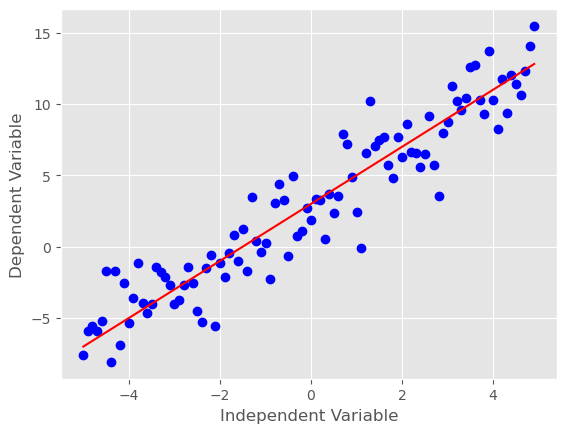

In [2]:
x = np.arange(-5.0, 5.0, 0.1)

y = 2*(x) + 3
y_noise = 2 * np.random.normal(size=x.size)
ydata = y + y_noise


plt.plot(x, ydata,  'bo')
plt.plot(x,y, 'r') 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')


Non-linear regression is a method to model the non-linear relationship between the independent variables $x$ and the dependent variable $y$. Essentially any relationship that is not linear can be termed as non-linear, and is usually represented by the polynomial of $k$ degrees (maximum power of $x$).  For example:

$$ \ y = a x^3 + b x^2 + c x + d \ $$

Non-linear functions can have elements like exponentials, logarithms, fractions, and so on. For example: $$ y = \log(x)$$
    
We can have a function that's even more complicated such as :
$$ y = \log(a x^3 + b x^2 + c x + d)$$


Text(0.5, 0, 'Independent Variable')

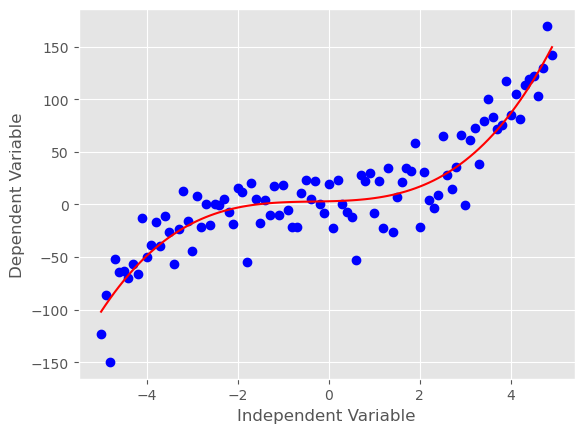

In [3]:
x = np.arange(-5.0, 5.0, 0.1)

y = 1*(x**3) + 1*(x**2) + 1*x + 3
y_noise = 20 * np.random.normal(size=x.size)
ydata = y + y_noise
plt.plot(x, ydata,  'bo')
plt.plot(x,y, 'r') 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')

As you can see, this function has $x^3$ and $x^2$ as independent variables. Also, the graphic of this function is not a straight line over the 2D plane. So this is a non-linear function.


Some other types of non-linear functions are:


### Quadratic


$$ Y = X^2 $$


Text(0.5, 0, 'Independent Variable')

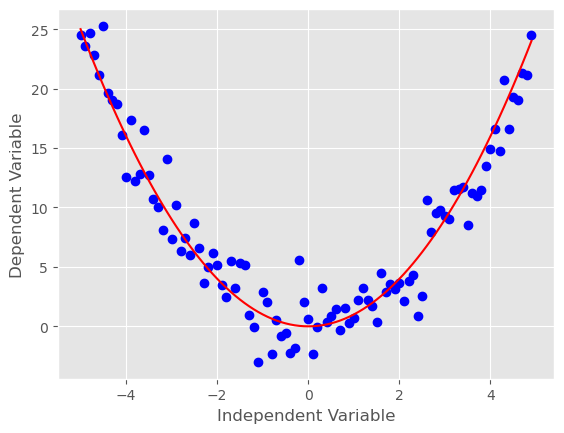

In [4]:
y = np.power(x,2)
y_noise = 2 * np.random.normal(size=x.size)
ydata = y + y_noise
plt.plot(x, ydata,  'bo')
plt.plot(x,y, 'r') 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')

### Exponential


An exponential function with base c is defined by $$ Y = a + b c^X$$ where b ≠0, c > 0 , c ≠1, and x is any real number. The base, c, is constant and the exponent, x, is a variable. 



Text(0.5, 0, 'Independent Variable')

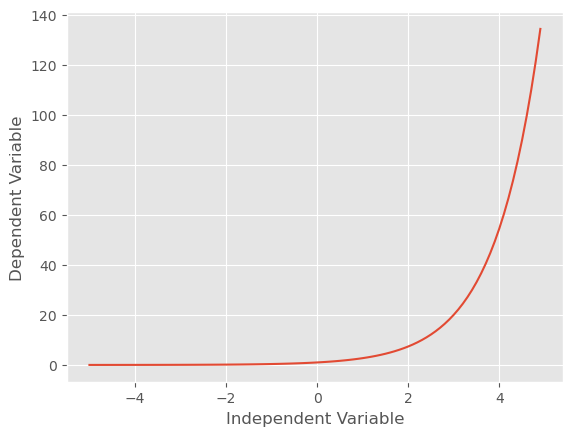

In [5]:
X = np.arange(-5.0, 5.0, 0.1)

Y= np.exp(X)

plt.plot(X,Y) 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')

### Logarithmic

The response $y$ is a results of applying the logarithmic map from the input $x$ to the output $y$. It is one of the simplest form of __log()__: i.e. $$ y = \log(x)$$

Please consider that instead of $x$, we can use $X$, which can be a polynomial representation of the $x$ values. In general form it would be written as  
\begin{equation}
y = \log(X)
\end{equation}


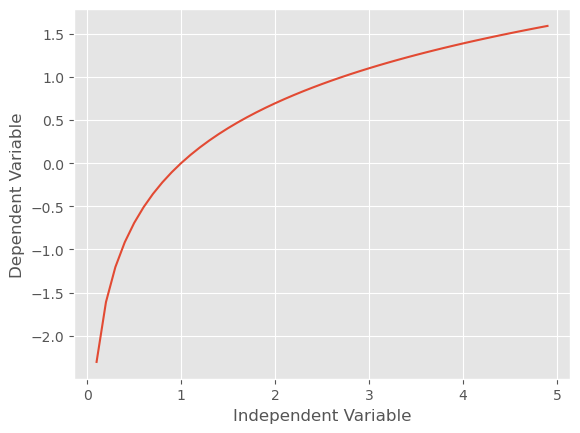

In [6]:
X = np.arange(0.1, 5.0, 0.1)

Y = np.log(X)

plt.plot(X,Y) 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

### Sigmoidal/Logistic


$$ Y = a + \frac{b}{1+ c^{(X-d)}}$$


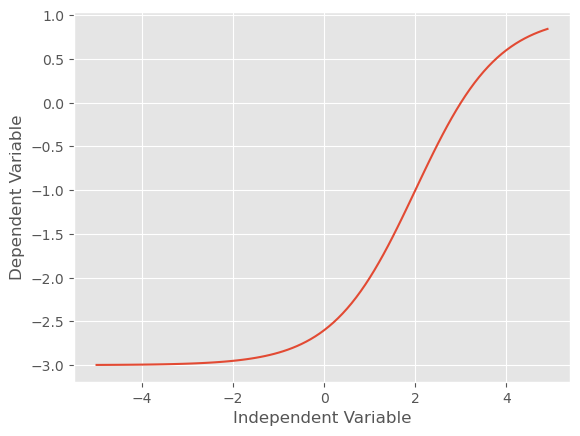

In [7]:
X = np.arange(-5.0, 5.0, 0.1)


Y = 1-4/(1+np.power(3, X-2))

plt.plot(X,Y) 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

## 📈 Non-Linear Regression Example: Modeling China's GDP Growth (1960–2014)

To see a real-world application of non-linear regression, we’ll use **China's GDP data** from 1960 to 2014. This dataset, commonly used in regression tutorials, reflects exponential or logistic growth — a classic case where linear regression fails to capture the underlying pattern.

### 📦 Dataset Information
- **Source**: World Bank or public repositories (e.g., Kaggle)
- **Features**:
  - `Year`: Time from 1960 to 2014
  - `GDP`: Gross Domestic Product in USD

We’ll visualize the data and then fit a logistic curve using `scipy.optimize.curve_fit` to perform non-linear regression.

Let’s load the dataset and begin the analysis!


In [8]:
df = pd.read_csv("china_gdp.csv")
df.head()

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10


### 📊 Plotting the Dataset

Before performing any modeling, it's crucial to visualize the data to understand its structure and trends.

By plotting China's GDP over time, we can:

- Observe the **overall growth pattern**
- Identify whether a **non-linear model** is appropriate
- Detect any **outliers or anomalies**

In this case, we expect to see a pattern resembling **logistic growth** — slow at the beginning, rapid in the middle years, and tapering off as it reaches a saturation point.

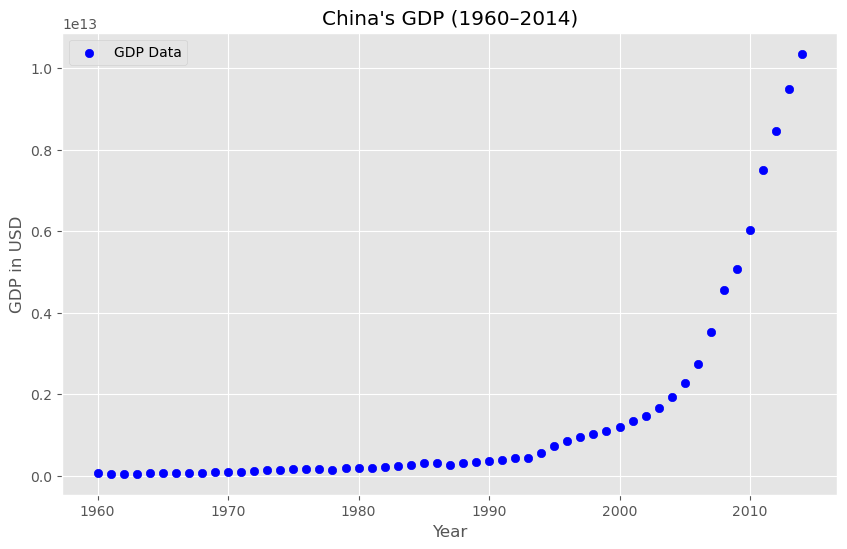

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Year"], df["Value"], color='blue', label='GDP Data')
plt.title("China's GDP (1960–2014)")
plt.xlabel("Year")
plt.ylabel("GDP in USD")
plt.legend()

### 🤔 Choosing a Model

From the scatter plot, China's GDP from 1960 to 2014 exhibits an **S-shaped curve**:
- **Slow initial growth** (pre-industrialization)
- **Rapid acceleration** (post-economic reforms)
- **Saturation phase** (as the economy matures)

This pattern is characteristic of **logistic growth**, making the **logistic function** a suitable choice for modeling.

---

### 📈 Logistic Growth Function

We will use the following logistic function for non-linear regression:

$$f(x) = \frac{L}{1 + e^{-k(x - x_0)}}$$

Where:
- $L$ = the curve’s maximum value (carrying capacity),
- $k$ = the growth rate,
- $x_0$ = the x-value of the sigmoid's midpoint.

This model allows us to capture the **non-linear and bounded** nature of GDP growth.

In the next step, we’ll use Python's `scipy.optimize.curve_fit()` function to fit this logistic curve to our data.


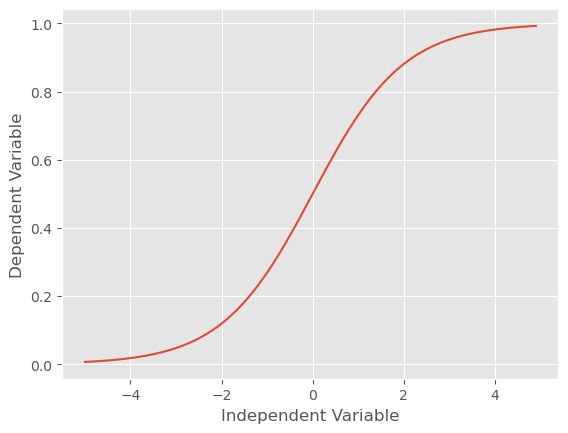

In [11]:
X = np.arange(-5.0, 5.0, 0.1)
Y = 1.0 / (1.0 + np.exp(-X))

plt.plot(X,Y) 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()



The formula for the logistic function is the following:

$$ \hat{Y} = \frac1{1+e^{-\beta_1(X-\beta_2)}}$$

$\beta_1$: Controls the curve's steepness,

$\beta_2$: Slides the curve on the x-axis.


### 🛠️ Building the Model

With our logistic function selected, we’re now ready to fit the model to the data.

To do this, we'll follow these steps:

1. **Define the logistic function**
2. **Use `scipy.optimize.curve_fit()`** to estimate the best parameters:
   - `L`: Maximum GDP value
   - `k`: Growth rate
   - `x₀`: Inflection point (year of fastest growth)

3. **Make predictions** using the fitted model.

4. **Visualize the fitted curve** against the actual GDP data.

---

### 🧠 Why Use `curve_fit`?

The `curve_fit()` function from `scipy.optimize` performs non-linear least squares fitting. It finds the optimal parameter values that minimize the error between the logistic function and the actual data.

This method is robust and ideal for non-linear models like ours.


In [12]:
def sigmoid(x, Beta_1, Beta_2):
    y = 1 / (1 + np.exp(-Beta_1*(x-Beta_2)))
    return y

Lets look at a sample sigmoid line that might fit with the data:


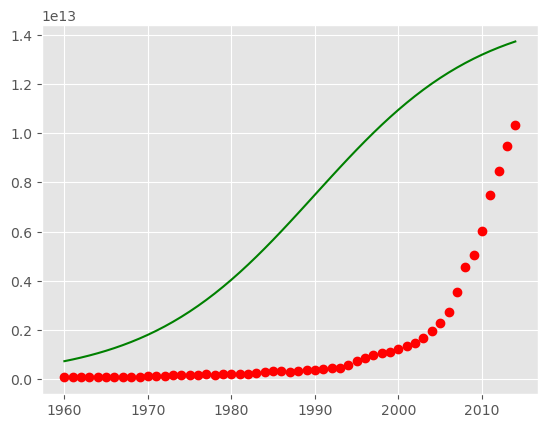

In [19]:
beta_1 = 0.10
beta_2 = 1990.0

#logistic function
Y_pred = sigmoid(df['Year'], beta_1 , beta_2)

#plot initial prediction against datapoints
plt.plot(df['Year'], Y_pred*15000000000000.,'green')
plt.plot(df['Year'], df["Value"], 'ro')

Our task here is to find the best parameters for our model. Lets first normalize our x and y:


In [22]:
xdata =df['Year']/max(df['Year'])
ydata =df["Value"]/max(df["Value"])

#### 📚 `curve_fit()` — Complete Explanation


| Parameter           | Description                                                                                                                                                 |
| ------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `f`                 | The **model function** to be fitted. It must take the independent variable as the first argument and the parameters to fit as separate remaining arguments. |
| `xdata`             | The **independent variable(s)** (e.g., years). Should be array-like.                                                                                        |
| `ydata`             | The **dependent variable** (e.g., GDP values) to be modeled. Should be array-like and of same length as `xdata`.                                            |
| `p0` (optional)     | Initial **guess for the parameters**. If not specified, all parameters are assumed to be 1. Providing good initial guesses helps with convergence.          |
| `bounds` (optional) | Lower and upper **bounds for the parameters** as a tuple: `(lower_bounds, upper_bounds)`. Default is `(-inf, inf)` (no bounds).                             |
| `sigma` (optional)  | Weights for the `ydata` — if specified, performs a weighted fit.                                                                                            |
| `absolute_sigma`    | If `True`, `sigma` is assumed to represent actual standard deviations of `ydata`.                                                                           |
| `maxfev`            | Maximum number of function evaluations. If the fit is not converging, increase this.                                                                        |

---

##### 📤 **Returns**

| Output | Description                                                                                                           |
| ------ | --------------------------------------------------------------------------------------------------------------------- |
| `popt` | Array of **optimal values** for the parameters that best fit the data.                                                |
| `pcov` | The **covariance matrix** of the parameter estimates. Diagonal values give the estimated variances of each parameter. |

_____
##### ⚠️ Common Tips

* Always **visualize** the data before choosing a model.
* Provide good **initial parameter guesses** (`p0`) for better performance.
* Check the **fit quality** by plotting the predicted curve vs. actual data.
* Use **`pcov`** to understand the **confidence** in parameter estimates.


In [23]:
popt, pcov = curve_fit(sigmoid, xdata, ydata)
print(" beta_1 = %f, beta_2 = %f" % (popt[0], popt[1]))

 beta_1 = 690.451712, beta_2 = 0.997207


Now we plot our resulting regression model.


Text(0.5, 0, 'Year')

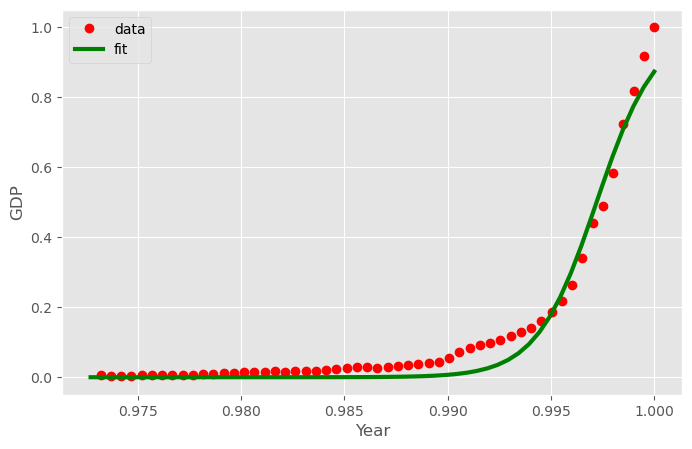

In [27]:
x = np.linspace(1960, 2015, 55)
x = x/max(x)
plt.figure(figsize=(8,5))
y = sigmoid(x, *popt)
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(x,y, linewidth=3.0,color='green', label='fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')

### Practice
Can you calculate what is the accuracy of our model?


In [28]:

msk = np.random.rand(len(df)) < 0.8
train_x = xdata[msk]
test_x = xdata[~msk]
train_y = ydata[msk]
test_y = ydata[~msk]

popt, pcov = curve_fit(sigmoid, train_x, train_y)

# predict using test set
y_hat = sigmoid(test_x, *popt)

# evaluation
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_hat - test_y) ** 2))
from sklearn.metrics import r2_score
print("R2-score: %.2f" % r2_score(test_y,y_hat) )


Mean absolute error: 0.04
Residual sum of squares (MSE): 0.00
R2-score: 0.75


### 📌 Interpretation:
- The **MAE** is very low, indicating that the model's predictions are close to the actual GDP values on average.
- The **MSE** being close to zero suggests very small squared errors, meaning the model doesn't produce large outliers.
- An **R² score of 0.75** implies that **75% of the variability** in GDP is explained by the logistic model — a reasonably strong fit, especially for real-world economic data.


Fitted parameters: a = 0.0000, b = 313.186731


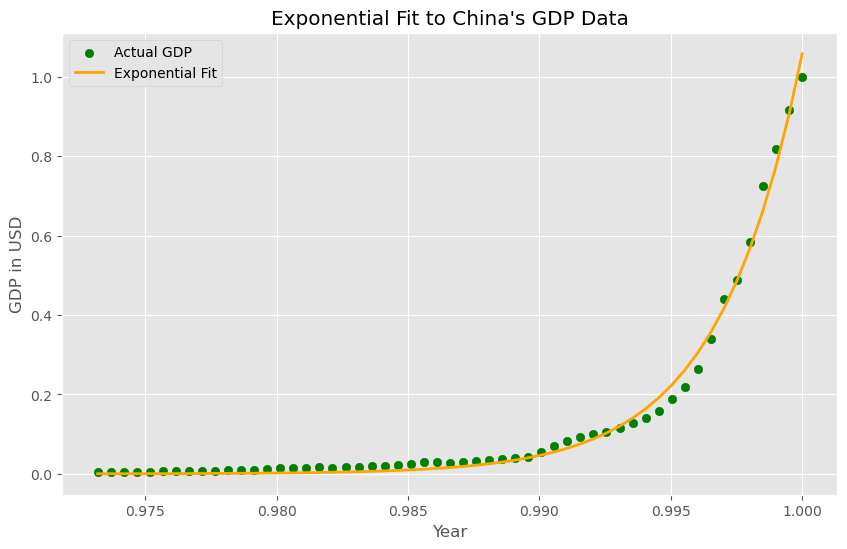

Mean Absolute Error (MAE): 0.01
Mean Squared Error (MSE): 0.00
R² Score: 0.99


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def exp_model(x, a, b):
    return a * np.exp(b * x)

initial_guess = [1, 0.01]

# Fit the model to the data
popt, pcov = curve_fit(exp_model, xdata, ydata, p0=initial_guess, maxfev=10000)

# Extract fitted parameters
a, b = popt
print(f"Fitted parameters: a = {a:.4f}, b = {b:.6f}")

# Predict using the fitted model
y_pred = exp_model(xdata, a, b)

# Plot actual data vs exponential fit
plt.figure(figsize=(10, 6))
plt.scatter(xdata, ydata, label="Actual GDP", color="green")
plt.plot(xdata, y_pred, label="Exponential Fit", color="orange", linewidth=2)
plt.xlabel("Year")
plt.ylabel("GDP in USD")
plt.title("Exponential Fit to China's GDP Data")
plt.legend()
plt.grid(True)
plt.show()

# Evaluation metrics
mae = mean_absolute_error(ydata, y_pred)
mse = mean_squared_error(ydata, y_pred)
r2 = r2_score(ydata, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


### ✅ **Overall Interpretation**

* The **exponential model fits China's GDP data extremely well** from 1960 to 2014.
* An **R² score of 0.99** means the model nearly **perfectly captures the growth trend**.
* The **low MAE and MSE** reinforce that the predictions are **very close to actual values** throughout the dataset.
* This suggests that during this period, **China's economic growth closely followed an exponential pattern**, which is typical of **early- to mid-stage rapid development**.

---

### ⚠️ A Note of Caution

While exponential growth fits the historical data very well:

* It **may not generalize to future years**, as real-world systems (like GDP) tend to **saturate** or slow down over time.
* That's where the **logistic model** becomes useful — it accounts for a **maximum capacity** or natural slowdown in growth.


# Greate Job


<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2006/Session%2006%20-%20Matplotlib%20Concepts_1.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>